<a href="https://colab.research.google.com/github/Alister44/DTA_2026_DE/blob/main/Unterrichtsaufgaben/pandas_lecture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🐼 Pandas: Einführung in die Datenanalyse

**Vorlesung • 1,5 Stunden**

---

## Was ist pandas?

**pandas** ist die beliebteste Python-Bibliothek für die Arbeit mit Tabellendaten. Wenn du schon mit Excel oder Google Sheets gearbeitet hast — pandas ist im Grunde dasselbe, aber:
- 🚀 deutlich schneller bei großen Datenmengen
- 🔁 alles wird per Code automatisiert (kein Klicken mit der Maus nötig)
- 🔗 lässt sich leicht mit Diagrammen, maschinellem Lernen und Datenbanken kombinieren

Das zentrale Objekt in pandas ist der **DataFrame** (eine Tabelle mit Zeilen und Spalten).

> 💡 **So arbeitest du mit dem Notebook:** Führe jede Zelle nacheinander aus (Shift + Enter) und schau dir das Ergebnis an. Experimentiere — ändere den Code und sieh, was sich ändert!

---



## 1. Import der Bibliothek

Traditionell wird pandas mit der Abkürzung `pd` importiert. Das ist allgemein üblich — so schreibt es jeder.


In [1]:
import pandas as pd

print("pandas-Version:", pd.__version__)


pandas-Version: 2.2.2


## 2. Daten laden

Heute arbeiten wir mit den Daten einer Café-Kette — das ist die Datei `coffee_sales.csv` mit Bestellungen über 6 Monate.

Um eine CSV-Datei zu lesen, verwenden wir `pd.read_csv()`. Das Ergebnis ist ein DataFrame, den wir üblicherweise in der Variable `df` speichern.


In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/Alister44/DTA_2026_DE/refs/heads/main/data/coffee_sales.csv")

# .head() zeigt die ersten 5 Zeilen
df.head()


,order_id,date,city,product,category,unit_price,quantity,discount_pct,revenue,manager
0,1255,2024-05-21,Lviv,Latte,Drinks,70,2,0,140.0,Olena
1,1299,2024-05-25,Harkiv,Tea,Drinks,40,2,5,76.0,Bohdan
2,1003,2024-01-14,Harkiv,Muffin,Baking,60,1,0,60.0,Olena
3,1226,2024-04-21,Lviv,Cappuccino,Drinks,65,1,0,65.0,Olena
4,1114,2024-02-16,Lviv,Latte,Drinks,70,1,10,63.0,Andrij


### Erster Blick auf die Daten

Ein paar der nützlichsten Befehle, um sich mit einem neuen Datensatz vertraut zu machen:


In [3]:
# Größe der Tabelle: (Zeilen, Spalten)
df.shape


(360, 10)

In [4]:
# Namen aller Spalten
df.columns


Index(['order_id', 'date', 'city', 'product', 'category', 'unit_price',
       'quantity', 'discount_pct', 'revenue', 'manager'],
      dtype='object')

In [5]:
# Allgemeine Informationen: Datentypen, Anzahl nicht-leerer Werte
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   order_id      360 non-null    int64  
 1   date          360 non-null    object 
 2   city          360 non-null    object 
 3   product       360 non-null    object 
 4   category      360 non-null    object 
 5   unit_price    360 non-null    int64  
 6   quantity      360 non-null    int64  
 7   discount_pct  360 non-null    int64  
 8   revenue       360 non-null    float64
 9   manager       360 non-null    object 
dtypes: float64(1), int64(4), object(5)
memory usage: 28.3+ KB


In [6]:
# Statistik zu den numerischen Spalten: Mittelwert, Min, Max usw.
df.describe()


,order_id,unit_price,quantity,discount_pct,revenue
count,360.000000,360.000000,360.000000,360.000000,360.000000
mean,1180.500000,73.972222,2.136111,1.472222,157.688889
std,104.067286,25.290497,1.192281,3.794778,109.374416
min,1001.000000,40.000000,1.000000,0.000000,38.000000
25%,1090.750000,55.000000,1.000000,0.000000,70.000000
50%,1180.500000,65.000000,2.000000,0.000000,120.000000
75%,1270.250000,95.000000,3.000000,0.000000,220.000000
max,1360.000000,120.000000,5.000000,15.000000,600.000000


> 💡 `.head(n)` zeigt die ersten `n` Zeilen, `.tail(n)` die letzten. Das ist das Allererste, was man mit jedem neuen Datensatz tun sollte.


In [7]:
# Die letzten 3 Zeilen
df.tail(3)


,order_id,date,city,product,category,unit_price,quantity,discount_pct,revenue,manager
357,1032,2024-01-10,Lviv,Sandwich,Food,95,4,0,380.0,Olena
358,1296,2024-05-04,Kyiv,Espresso,Drinks,45,4,0,180.0,Olena
359,1196,2024-04-05,Odesa,Tea,Drinks,40,1,5,38.0,Maria


## 3. Spalten auswählen

Um eine einzelne Spalte auszuwählen, verwenden wir eckige Klammern mit dem Spaltennamen.


In [8]:
# Eine Spalte (gibt eine Series zurück - eine eindimensionale Spalte)
df["city"].value_counts()


,count
city,
Kyiv,100
Lviv,88
Odesa,88
Harkiv,84


In [9]:
# Mehrere Spalten (gibt einen DataFrame zurück - doppelte Klammern!)
df[["product", "revenue"]].head()


,product,revenue
0,Latte,140.0
1,Tea,76.0
2,Muffin,60.0
3,Cappuccino,65.0
4,Latte,63.0


### Grundlegende Operationen mit einer Spalte

Mit einer numerischen Spalte kann man sofort Aggregate berechnen:


In [10]:
print("Gesamtumsatz:", df["revenue"].sum())
print("Durchschnittsumsatz:", df["revenue"].mean())
print("Maximalumsatz:", df["revenue"].max())
print("Minimalumsatz:", df["revenue"].min())
print("Anzahl der Bestellungen:", df["revenue"].count())


Gesamtumsatz: 56768.0
Durchschnittsumsatz: 157.6888888888889
Maximalumsatz: 600.0
Minimalumsatz: 38.0
Anzahl der Bestellungen: 360


In [11]:
# Wie viele einzigartige Städte gibt es?
df["city"].unique()


array(['Lviv', 'Harkiv', 'Kyiv', 'Odesa'], dtype=object)

In [12]:
# Wie viele Bestellungen gibt es in jeder Stadt? value_counts() - ein sehr nützlicher Befehl!
df["city"].value_counts()


,count
city,
Kyiv,100
Lviv,88
Odesa,88
Harkiv,84


## 4. Zeilen filtern

Das ist eine der wichtigsten Operationen. Wir wollen nur die Zeilen auswählen, die einer Bedingung entsprechen.

Prinzip: innerhalb von `df[...]` schreiben wir eine Bedingung, die für jede Zeile `True`/`False` zurückgibt.


In [13]:
# Nur Bestellungen aus Kyjiw
kyiv_orders = df[df["city"] == "Kyiv"]
kyiv_orders.head()


,order_id,date,city,product,category,unit_price,quantity,discount_pct,revenue,manager
5,1164,2024-03-20,Kyiv,Cheesecake,Desserts,110,2,0,220.0,Maria
6,1338,2024-06-02,Kyiv,Tiramisu,Desserts,120,3,0,360.0,Andrij
8,1169,2024-03-18,Kyiv,Muffin,Baking,60,1,0,60.0,Andrij
9,1193,2024-04-27,Kyiv,Latte,Drinks,70,5,0,350.0,Olena
11,1170,2024-03-10,Kyiv,Espresso,Drinks,45,1,0,45.0,Maria


In [14]:
# Wie viele Bestellungen aus Kyjiw?
len(kyiv_orders)


100

In [15]:
# Bestellungen mit einem Umsatz über 200 UAH
big_orders = df[df["revenue"] > 200]
print("Große Bestellungen:", len(big_orders))
big_orders.head()


Große Bestellungen: 100


,order_id,date,city,product,category,unit_price,quantity,discount_pct,revenue,manager
5,1164,2024-03-20,Kyiv,Cheesecake,Desserts,110,2,0,220.0,Maria
6,1338,2024-06-02,Kyiv,Tiramisu,Desserts,120,3,0,360.0,Andrij
9,1193,2024-04-27,Kyiv,Latte,Drinks,70,5,0,350.0,Olena
13,1213,2024-04-20,Lviv,Cappuccino,Drinks,65,4,0,260.0,Andrij
16,1059,2024-01-22,Kyiv,Muffin,Baking,60,4,0,240.0,Andrij


### Mehrere Bedingungen gleichzeitig

Um Bedingungen zu kombinieren, verwenden wir `&` (UND) und `|` (ODER). **Wichtig:** jede Bedingung muss in Klammern stehen!


In [16]:
# Bestellungen aus Kyjiw UND mit Umsatz über 150
result = df[(df["city"] == "Kyiv") & (df["revenue"] > 150)]
result.head()


,order_id,date,city,product,category,unit_price,quantity,discount_pct,revenue,manager
5,1164,2024-03-20,Kyiv,Cheesecake,Desserts,110,2,0,220.0,Maria
6,1338,2024-06-02,Kyiv,Tiramisu,Desserts,120,3,0,360.0,Andrij
9,1193,2024-04-27,Kyiv,Latte,Drinks,70,5,0,350.0,Olena
16,1059,2024-01-22,Kyiv,Muffin,Baking,60,4,0,240.0,Andrij
19,1192,2024-04-26,Kyiv,Sandwich,Food,95,4,0,380.0,Andrij


In [17]:
# Bestellungen aus der Kategorie Desserts ODER Baking
sweets = df[(df["category"] == "Desserts") | (df["category"] == "Baking")]
print("Süße Bestellungen:", len(sweets))
sweets.head()


Süße Bestellungen: 146


,order_id,date,city,product,category,unit_price,quantity,discount_pct,revenue,manager
2,1003,2024-01-14,Harkiv,Muffin,Baking,60,1,0,60.0,Olena
5,1164,2024-03-20,Kyiv,Cheesecake,Desserts,110,2,0,220.0,Maria
6,1338,2024-06-02,Kyiv,Tiramisu,Desserts,120,3,0,360.0,Andrij
7,1044,2024-01-01,Harkiv,Cheesecake,Desserts,110,1,0,110.0,Olena
8,1169,2024-03-18,Kyiv,Muffin,Baking,60,1,0,60.0,Andrij


> 💡 Ein häufiger Fehler: `and`/`or` statt `&`/`|` zu schreiben. In pandas werden für die Filterung genau die Zeichen `&` und `|` verwendet, und jede Bedingung muss in Klammern stehen.


## 5. Neue Spalten erstellen

Sehr oft muss man etwas Neues auf Basis der vorhandenen Daten berechnen. Eine neue Spalte wird ganz einfach erstellt — man weist einer neuen Bezeichnung einen Wert zu.


In [18]:
# Berechnen wir den Umsatz ohne Rabatt (voller Preis)
df["full_price"] = df["unit_price"] * df["quantity"]
df.head()


,order_id,date,city,product,category,unit_price,quantity,discount_pct,revenue,manager,full_price
0,1255,2024-05-21,Lviv,Latte,Drinks,70,2,0,140.0,Olena,140
1,1299,2024-05-25,Harkiv,Tea,Drinks,40,2,5,76.0,Bohdan,80
2,1003,2024-01-14,Harkiv,Muffin,Baking,60,1,0,60.0,Olena,60
3,1226,2024-04-21,Lviv,Cappuccino,Drinks,65,1,0,65.0,Olena,65
4,1114,2024-02-16,Lviv,Latte,Drinks,70,1,10,63.0,Andrij,70


In [19]:
# Wie viel UAH wurde durch den Rabatt verloren?
df["discount_amount"] = df["full_price"] - df["revenue"]
df.head()


,order_id,date,city,product,category,unit_price,quantity,discount_pct,revenue,manager,full_price,discount_amount
0,1255,2024-05-21,Lviv,Latte,Drinks,70,2,0,140.0,Olena,140,0.0
1,1299,2024-05-25,Harkiv,Tea,Drinks,40,2,5,76.0,Bohdan,80,4.0
2,1003,2024-01-14,Harkiv,Muffin,Baking,60,1,0,60.0,Olena,60,0.0
3,1226,2024-04-21,Lviv,Cappuccino,Drinks,65,1,0,65.0,Olena,65,0.0
4,1114,2024-02-16,Lviv,Latte,Drinks,70,1,10,63.0,Andrij,70,7.0


> 💡 Operationen werden sofort auf die GESAMTE Spalte angewendet — es ist keine Schleife nötig! Das nennt man „Vektorisierung“ und ist einer der Hauptvorteile von pandas.


## 6. Sortieren

`sort_values()` sortiert die Tabelle nach der angegebenen Spalte.


In [20]:
# Top-5 größte Bestellungen nach Umsatz
df.sort_values("revenue", ascending=False).head()


,order_id,date,city,product,category,unit_price,quantity,discount_pct,revenue,manager,full_price,discount_amount
239,1029,2024-01-16,Kyiv,Tiramisu,Desserts,120,5,0,600.0,Maria,600,0.0
78,1135,2024-03-27,Lviv,Tiramisu,Desserts,120,5,0,600.0,Andrij,600,0.0
23,1248,2024-05-24,Lviv,Cheesecake,Desserts,110,5,0,550.0,Olena,550,0.0
344,1115,2024-02-05,Harkiv,Cheesecake,Desserts,110,5,0,550.0,Andrij,550,0.0
302,1076,2024-02-01,Harkiv,Cheesecake,Desserts,110,5,5,522.5,Olena,550,27.5


In [21]:
# Günstigste Bestellungen (aufsteigend)
df.sort_values("revenue", ascending=True).head()


,order_id,date,city,product,category,unit_price,quantity,discount_pct,revenue,manager,full_price,discount_amount
359,1196,2024-04-05,Odesa,Tea,Drinks,40,1,5,38.0,Maria,40,2.0
300,1237,2024-04-09,Harkiv,Tea,Drinks,40,1,5,38.0,Andrij,40,2.0
30,1243,2024-05-27,Odesa,Tea,Drinks,40,1,0,40.0,Bohdan,40,0.0
28,1017,2024-01-25,Lviv,Tea,Drinks,40,1,0,40.0,Maria,40,0.0
339,1160,2024-03-09,Odesa,Tea,Drinks,40,1,0,40.0,Andrij,40,0.0


## 7. Gruppieren — `groupby()` 🔥

Das ist das mächtigste Werkzeug von pandas und das Herzstück der Datenanalyse. Die Idee: die Daten in Gruppen aufteilen und für jede Gruppe etwas berechnen.

**Analogie:** das ist dasselbe wie eine Pivot-Tabelle in Excel.

Schema: `df.groupby("Spalte")["was_berechnen"].Aggregat()`


In [22]:
# Gesamtumsatz pro Stadt
df.groupby("city")["revenue"].sum()


,revenue
city,
Harkiv,13588.5
Kyiv,15465.0
Lviv,14726.0
Odesa,12988.5


In [23]:
# Durchschnittsumsatz pro Kategorie
df.groupby("category")["revenue"].mean()


,revenue
category,
Baking,117.700658
Desserts,253.064286
Drinks,129.379888
Food,198.550000


In [24]:
# Anzahl der Bestellungen pro Manager
df_grouped = df.groupby("manager")["order_id"].count()
df_grouped


,order_id
manager,
Andrij,118
Bohdan,78
Maria,77
Olena,87


In [25]:
list(df_grouped.index)

['Andrij', 'Bohdan', 'Maria', 'Olena']

### Das Ergebnis der Gruppierung sortieren

Das Ergebnis von groupby sind auch Daten, die man sortieren kann. Oft möchten wir die Spitzenreiter sehen.


In [26]:
# Top-Produkte nach Gesamtumsatz
df.groupby("product")["revenue"].sum().sort_values(ascending=False)


,revenue
product,
Cheesecake,9740.50
Tiramisu,7974.00
Sandwich,6949.25
Raffle,6719.25
Latte,5747.00
Muffin,4845.00
Cappuccino,4751.50
Croissant,4100.25
Tea,3176.00


### Mehrere Aggregate gleichzeitig

Die Methode `.agg()` ermöglicht es, mehrere Kennzahlen auf einmal zu berechnen.


In [27]:
# Nach Städten: Summe, Durchschnitt und Anzahl der Bestellungen
df.groupby("city")["revenue"].agg(["sum", "mean", "count"])


,sum,mean,count
city,,,
Harkiv,13588.5,161.767857,84
Kyiv,15465.0,154.650000,100
Lviv,14726.0,167.340909,88
Odesa,12988.5,147.596591,88


In [28]:
# Gruppierung nach ZWEI Spalten: Stadt + Kategorie
df.groupby(["city", "category"])["revenue"].sum()


city    category
Harkiv  Baking      1481.75
        Desserts    3886.00
        Drinks      6235.25
        Food        1985.50
Kyiv    Baking      3020.00
        Desserts    5279.50
        Drinks      5184.75
        Food        1980.75
Lviv    Baking      2131.00
        Desserts    4692.00
        Drinks      6136.00
        Food        1767.00
Odesa   Baking      2312.50
        Desserts    3857.00
        Drinks      5603.00
        Food        1216.00
Name: revenue, dtype: float64

## 8. Arbeiten mit Datumsangaben

Momentan ist die Spalte `date` einfach nur Text. Um damit als Datum arbeiten zu können (Monat, Jahr extrahieren), muss man sie mit `pd.to_datetime()` umwandeln.


In [29]:
# Wandeln den Text in ein Datum um
df["date"] = pd.to_datetime(df["date"])
df["date"].head()


,date
0,2024-05-21
1,2024-05-25
2,2024-01-14
3,2024-04-21
4,2024-02-16


In [30]:
# Jetzt können wir Monat, Jahr, Wochentag extrahieren
df["month"] = df["date"].dt.month
df["day_name"] = df["date"].dt.day_name()
df[["date", "month", "day_name"]].head()


,date,month,day_name
0,2024-05-21,5,Tuesday
1,2024-05-25,5,Saturday
2,2024-01-14,1,Sunday
3,2024-04-21,4,Sunday
4,2024-02-16,2,Friday


In [31]:
# Umsatz nach Monaten - klassische Zeitreihenanalyse
df.groupby("month")["revenue"].sum()


,revenue
month,
1,9624.25
2,9632.25
3,8540.25
4,9571.00
5,9808.50
6,9591.75


## 9. Alles zusammenfügen: Mini-Analyse

Jetzt wenden wir alles Gelernte an, um echte Geschäftsfragen zu den Cafés zu beantworten.


**Frage 1:** Welche Stadt bringt das meiste Geld ein?


In [32]:
revenue_by_city = df.groupby("city")["revenue"].sum().sort_values(ascending=False)
print(revenue_by_city)
print()
print("Spitzenreiter:", revenue_by_city.index[0])


city
Kyiv      15465.0
Lviv      14726.0
Harkiv    13588.5
Odesa     12988.5
Name: revenue, dtype: float64

Spitzenreiter: Kyiv


**Frage 2:** Welche 3 Produkte sind am profitabelsten?


In [33]:
top_products = df.groupby("product")["revenue"].sum().sort_values(ascending=False)
top_products.head(3)

,revenue
product,
Cheesecake,9740.50
Tiramisu,7974.00
Sandwich,6949.25


**Frage 3:** Welcher Manager hat am meisten verkauft?


In [34]:
df.groupby("manager")["revenue"].sum().sort_values(ascending=False).head(1)

,revenue
manager,
Andrij,19540.5


**Frage 4:** Wie hat sich der Umsatz von Monat zu Monat verändert?


month
1    9624.25
2    9632.25
3    8540.25
4    9571.00
5    9808.50
6    9591.75
Name: revenue, dtype: float64


<Axes: title={'center': 'Umsatz nach Monaten'}, xlabel='month'>

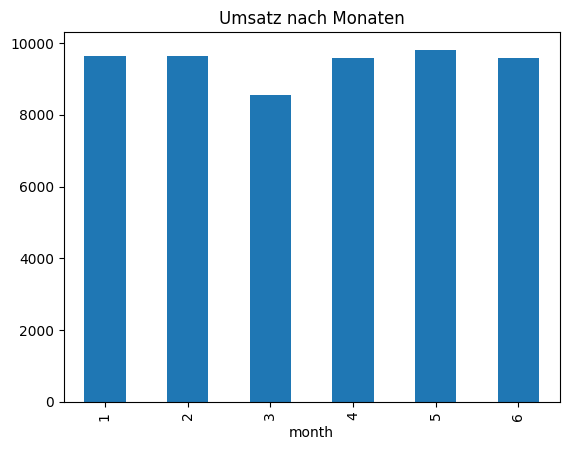

In [35]:
monthly = df.groupby("month")["revenue"].sum()
print(monthly)

# Man kann sogar direkt in pandas schnell ein Diagramm erstellen!
monthly.plot(kind="bar", title="Umsatz nach Monaten")


> 💡 pandas kann schnelle Diagramme über `.plot()` erstellen. Für ernsthafte Visualisierungen werden matplotlib oder seaborn verwendet, aber für einen schnellen Blick ist `.plot()` ideal.


---

# 🎯 Übungsaufgaben

Jetzt bist du dran! Versuche, diese Aufgaben selbstständig zu lösen. Die Daten sind bereits in `df` geladen.

Wenn etwas nicht klappt — schau dir die Beispiele oben noch einmal an, sie enthalten alles Nötige.


### Aufgabe 1 ⭐
Gib die ersten 10 Zeilen der Tabelle aus.


In [36]:
# Dein Code:




### Aufgabe 2 ⭐
Finde heraus, wie viele einzigartige Produkte es insgesamt in den Daten gibt.

Tipp: die Methode `.nunique()` zählt die Anzahl der einzigartigen Werte.


In [37]:
# Dein Code:




### Aufgabe 3 ⭐
Gib alle Bestellungen aus der Stadt Lwiw aus.


In [38]:
# Dein Code:




### Aufgabe 4 ⭐⭐
Finde alle Bestellungen, bei denen ein Rabatt angewendet wurde (discount_pct größer als 0).
Wie viele solcher Bestellungen gibt es?


In [39]:
# Dein Code:




### Aufgabe 5 ⭐⭐
Erstelle eine neue Spalte `is_big`, die `True` ist, wenn der Umsatz größer als 150 ist, und sonst `False`.

Tipp: `df["is_big"] = df["revenue"] > 150`


In [40]:
# Dein Code:




### Aufgabe 6 ⭐⭐
Berechne den Gesamtumsatz für jede Produktkategorie (Drinks, Baking, Desserts, Food).
Sortiere absteigend.


In [41]:
# Dein Code:




### Aufgabe 7 ⭐⭐
Wie hoch ist die durchschnittliche Anzahl der Produkte (quantity) pro Bestellung in jeder Stadt?


In [42]:
# Dein Code:




### Aufgabe 8 ⭐⭐⭐
Finde das profitabelste Produkt in JEDER Stadt.

Tipp: gruppiere nach den zwei Spalten `["city", "product"]`, berechne die Umsatzsumme, und überlege dann, wie man das Maximum in jeder Stadt findet (schau dir `.idxmax()` an oder sortiere).


In [43]:
# Dein Code:




### Aufgabe 9 ⭐⭐⭐
Berechne, welcher Prozentsatz des Gesamtumsatzes des Unternehmens auf jede Stadt entfällt.

Tipp: berechne zuerst den Umsatz nach Städten, teile ihn dann durch die Gesamtsumme und multipliziere mit 100.


In [44]:
# Dein Code:




### Aufgabe 10 ⭐⭐⭐
An welchem Wochentag verdienen die Cafés am meisten?

Tipp: du brauchst die Spalte `day_name`, die wir vorhin erstellt haben. Gruppiere danach.


In [45]:
# Dein Code:




---

# 🎉 Ausgezeichnet!

Heute hast du die Grundlagen von pandas kennengelernt:

- ✅ Daten aus CSV laden (`read_csv`)
- ✅ Erster Blick auf die Daten (`head`, `info`, `describe`, `shape`)
- ✅ Spalten auswählen
- ✅ Zeilen nach Bedingungen filtern
- ✅ Neue Spalten erstellen
- ✅ Sortieren (`sort_values`)
- ✅ Gruppieren (`groupby`) — das Wichtigste!
- ✅ Arbeiten mit Datumsangaben
- ✅ Schnelle Diagramme (`.plot()`)

### Wie geht es weiter?
- Die Methode `merge()` — mehrere Tabellen zusammenführen (wie JOIN in SQL)
- Pivot-Tabellen (`pivot_table`)
- Umgang mit fehlenden Werten (`fillna`, `dropna`)
- Ernsthafte Visualisierung mit matplotlib und seaborn

**pandas ist das Fundament der Datenanalyse in Python. Übe fleißig! 🐼**

